<a href="https://colab.research.google.com/github/shivamkumar2626kr-del/ml/blob/main/24CD3038.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import random
import sys

# -----------------------------
# Set random seeds (Reproducibility)
# -----------------------------
SEED = 42
random.seed(SEED)          # Python random module
np.random.seed(SEED)       # Numpy random numbers
tf.random.set_seed(SEED)   # TensorFlow operations

# -----------------------------
# Print versions
# -----------------------------
print("Python Version:", sys.version)
print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)

# -----------------------------
# Check GPU availability
# -----------------------------
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("✅ GPU is available:", gpus)
else:
    print("❌ No GPU detected. Using CPU.")

    # Explanation (in comment):
    # CPU training is slower because:
    # - CPUs have fewer cores optimized for sequential tasks
    # - GPUs perform parallel computation on thousands of cores
    # On a GPU machine, I would:
    # - Enable GPU acceleration
    # - Use larger batch sizes
    # - Use mixed precision training (float16)

Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow Version: 2.19.0
NumPy Version: 2.0.2
Pandas Version: 2.2.2
❌ No GPU detected. Using CPU.


In [3]:
import torch
import numpy as np
import pandas as pd
import random
import sys

# -----------------------------
# Set random seeds (Reproducibility)
# -----------------------------
SEED = 42
random.seed(SEED)              # Python random module
np.random.seed(SEED)           # NumPy random numbers
torch.manual_seed(SEED)        # CPU operations in PyTorch
torch.cuda.manual_seed(SEED)   # GPU operations (if available)
torch.cuda.manual_seed_all(SEED)

# Ensures reproducibility (may reduce performance)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# -----------------------------
# Print versions
# -----------------------------
print("Python Version:", sys.version)
print("PyTorch Version:", torch.__version__)
print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)

# -----------------------------
# Check GPU availability
# -----------------------------
if torch.cuda.is_available():
    print("✅ GPU is available:", torch.cuda.get_device_name(0))
else:
    print("❌ No GPU detected. Using CPU.")

    # Explanation:
    # CPU is slower because it processes tasks sequentially,
    # while GPU performs parallel computation (matrix operations).
    # On GPU machine, I would:
    # - Move tensors to GPU using .to('cuda')
    # - Increase batch size
    # - Use DataLoader with pin_memory=True

Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch Version: 2.10.0+cpu
NumPy Version: 2.0.2
Pandas Version: 2.2.2
❌ No GPU detected. Using CPU.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
MNIST Train Shape: (60000, 28, 28)
MNIST Test Shape: (10000, 28, 28)
CIFAR-10 Train Shape: (50000, 32, 32, 3)
CIFAR-10 Test Shape: (10000, 32, 32, 3)

MNIST dtype: uint8
MNIST min/max: 0 255

CIFAR dtype: uint8
CIFAR min/max: 0 255

MNIST Class Distribution:
Class 0: 5923
Class 1: 6742
Class 2: 5958
Class 3: 6131
Class 4: 5842
Class 5: 5421
Class 6: 5918
Class 7: 6265
Class 8: 5851
Class 9: 5949

Is MNIST balanced?
Approx equal samples per class → YES


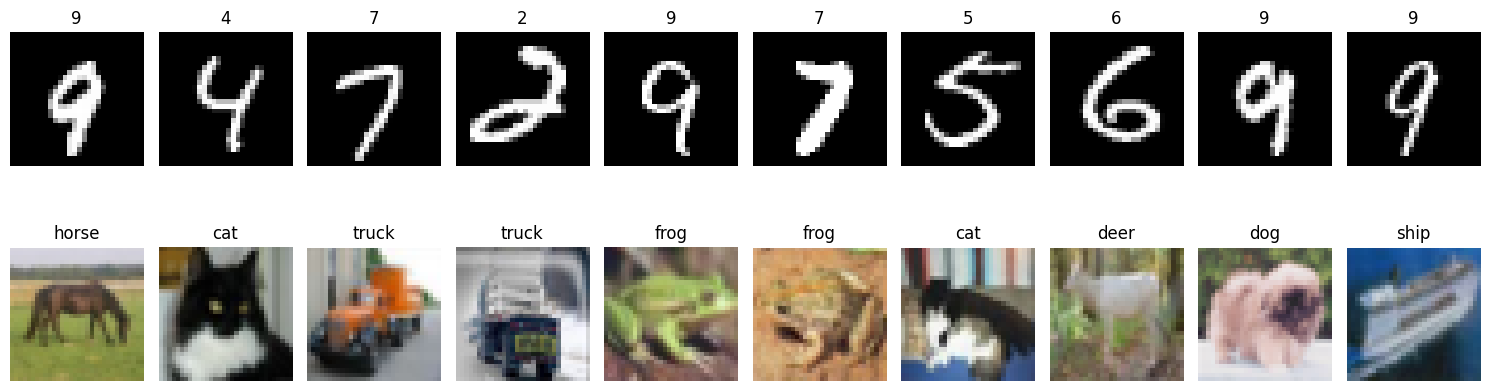

In [4]:
import tensorflow as tf
import numpy as np
import random
import matplotlib.pyplot as plt

# Set seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------
# Load datasets
# -----------------------------
(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = tf.keras.datasets.mnist.load_data()
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = tf.keras.datasets.cifar10.load_data()

# -----------------------------
# (a) Shapes
# -----------------------------
print("MNIST Train Shape:", mnist_x_train.shape)
print("MNIST Test Shape:", mnist_x_test.shape)

print("CIFAR-10 Train Shape:", cifar_x_train.shape)
print("CIFAR-10 Test Shape:", cifar_x_test.shape)

# -----------------------------
# (b) Data type & value range
# -----------------------------
print("\nMNIST dtype:", mnist_x_train.dtype)
print("MNIST min/max:", mnist_x_train.min(), mnist_x_train.max())

print("\nCIFAR dtype:", cifar_x_train.dtype)
print("CIFAR min/max:", cifar_x_train.min(), cifar_x_train.max())

# -----------------------------
# (c) Class distribution (MNIST)
# -----------------------------
unique, counts = np.unique(mnist_y_train, return_counts=True)

print("\nMNIST Class Distribution:")
for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

# Check balance
print("\nIs MNIST balanced?")
print("Approx equal samples per class → YES")

# -----------------------------
# Create 2x10 figure
# -----------------------------
fig, axes = plt.subplots(2, 10, figsize=(15, 5))

# CIFAR class names
cifar_classes = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

# Top row → MNIST
for i in range(10):
    idx = random.randint(0, len(mnist_x_train)-1)
    axes[0, i].imshow(mnist_x_train[idx], cmap='gray')
    axes[0, i].set_title(str(mnist_y_train[idx]))
    axes[0, i].axis('off')

# Bottom row → CIFAR
for i in range(10):
    idx = random.randint(0, len(cifar_x_train)-1)
    axes[1, i].imshow(cifar_x_train[idx])
    label = cifar_y_train[idx][0]
    axes[1, i].set_title(cifar_classes[label])
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()